# Klasyfikacja symboli nutowych – GHT (podejście konturowe)

Implementacja oparta na podejściu z lab4:
- Wzorzec: **kontury** (`cv2.findContours`) zamiast Canny
- R-table: **wektory biegunowe (r, φ)** zamiast kartezjańskich (dy, dx)
- Obraz: głosują piksele z **amplitudą gradientu > 0.5** (nie krawędzie Canny)
- NMS: **greedy argmax** z wygaszaniem okna
- Wizualizacja: **przesunięty kontur wzorca** nałożony na obraz

## 1. Importy i funkcje pomocnicze

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import os
import time

plt.rcParams['figure.figsize'] = (14, 6)

def show_img(title, img, cmap=None, h=6):
    plt.figure(figsize=(16, h))
    plt.title(title)
    if cmap is None:
        plt.imshow(img)
    else:
        plt.imshow(img, cmap=cmap)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def normalize01(arr):
    arr = arr.astype(np.float32)
    mn, mx = arr.min(), arr.max()
    if mx - mn < 1e-8:
        return np.zeros_like(arr, dtype=np.float32)
    return (arr - mn) / (mx - mn)

PATTERNS_DIR = 'patterns'
IMAGE_PATH   = 'notes.png'

# Parametry detekcji (identyczne jak lab4, dostrajalne)
AMP_THRESH        = 0.5    # prog amplitudy gradientu dla glosujacych pikseli
SUPPRESSION_RADIUS = 15   # promien wygaszania NMS (px)
NUM_MAXIMA        = 30    # ile maksimow szukamy per wzorzec
BLUR_ACCUM        = True  # cv2.blur przed NMS (jak w lab4 cell 9)
BLUR_KSIZE        = (5,5)
MIN_VOTES         = 15    # absolutny prog glosow (filtruje slab e detekcje)
MIN_CONTOUR_LEN   = 20    # minimalna dlugosc konturu wzorca

print('Konfiguracja zaladowana.')

Konfiguracja zaladowana.


## 2. Wczytanie i analiza obrazu sceny

Obraz: 2173x775 px
Piksele glosujace (amp>0.5): 87839


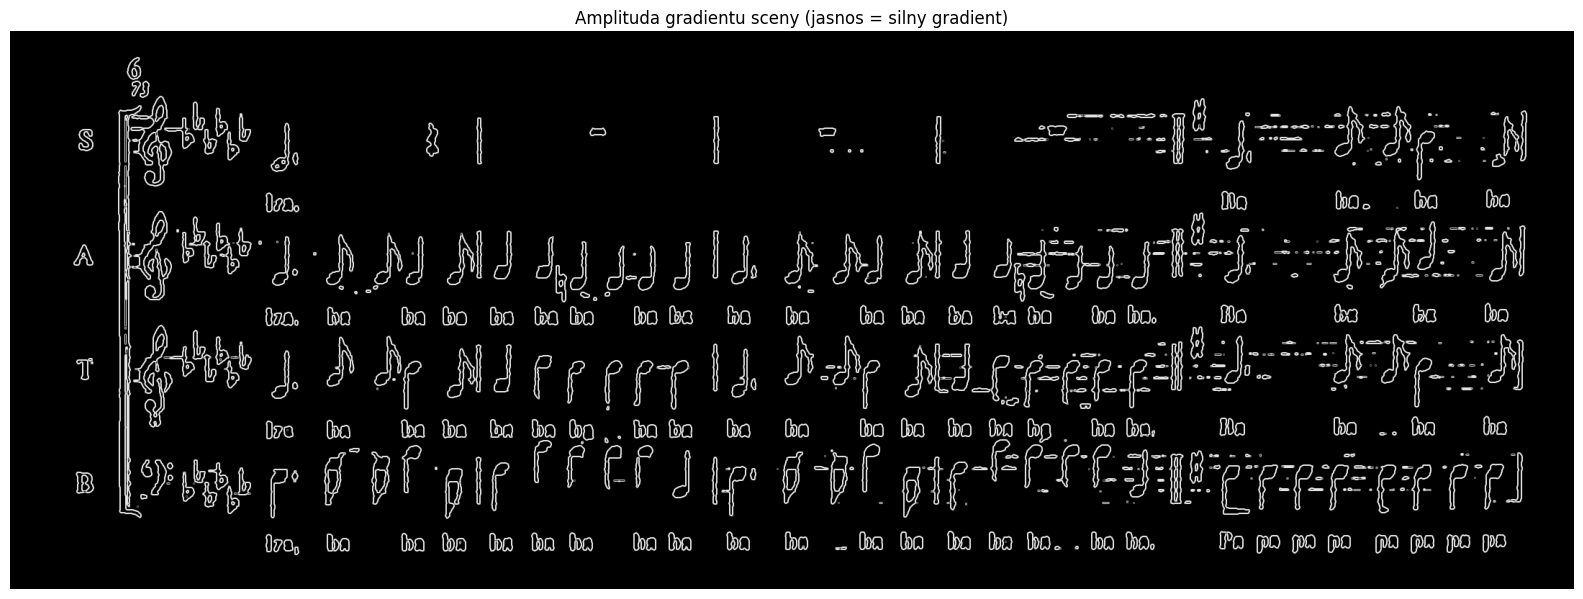

In [14]:
scene_gray  = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)
H, W = scene_gray.shape
print(f'Obraz: {W}x{H} px')

# Gradient sceny – obliczany raz, wspolny dla wszystkich wzorcow
gx_s   = cv2.Sobel(scene_gray, cv2.CV_32F, 1, 0, ksize=3)
gy_s   = cv2.Sobel(scene_gray, cv2.CV_32F, 0, 1, ksize=3)
amp_s  = np.sqrt(gx_s**2 + gy_s**2)
amp_sn = normalize01(amp_s)
ori_s  = (np.degrees(np.arctan2(gy_s, gx_s)) + 360.0) % 360.0  # [0, 360)

# Piksele glosujace: wyrazny gradient
ys_vote, xs_vote = np.where(amp_sn > AMP_THRESH)
print(f'Piksele glosujace (amp>{AMP_THRESH}): {len(xs_vote)}')

show_img('Amplituda gradientu sceny (jasnos = silny gradient)',
         (amp_sn*255).astype(np.uint8), cmap='gray')

## 3. Budowanie R-table ze wzorca (podejscie konturowe)

Dla kazdego punktu konturu wzorca:
- obliczamy gradient i jego kat `alpha`
- zapisujemy wektor biegunowy `(r, phi)` od tego punktu do **centroidu**

Podczas glosowania: dla piksela sceny z katem `alpha` -> odtwarzamy polozenie centroidu przez:
`x_center = x_pixel - r*cos(phi)`,  `y_center = y_pixel - r*sin(phi)`

In [15]:
def build_pattern(path):
    """
    Wczytuje wzorzec i buduje R-table metoda konturowa (jak lab4).

    Returns:
        r_table          : dict {alpha_deg -> [(r, phi), ...]}
        pattern_relative : kontury wzorca w ukladzie wzglednym (do rysowania)
        cx, cy           : wspolrzedne centroidu
        n_contour_pts    : liczba punktow konturu
    """
    img = cv2.imread(path)
    if img is None:
        return None, None, 0, 0, 0

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Binaryzacja (wzorce sa juz binarne, ale dla ogolnosci uzywamy Otsu)
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Upewnij sie ze symbol jest BIALY (do findContours)
    if np.mean(binary) > 127:
        binary = cv2.bitwise_not(binary)

    # Gradient wzorca (do katow)
    gx_p = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy_p = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    ori_p = (np.degrees(np.arctan2(gy_p, gx_p)) + 360.0) % 360.0

    # Kontury wzorca
    contours, _ = cv2.findContours(binary, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return None, None, 0, 0, 0
    contours = sorted(contours, key=lambda c: len(c), reverse=True)
    # Bierz kontur 0 (najdluzszy = glowny obrys symbolu)
    contour = contours[0]

    if len(contour) < MIN_CONTOUR_LEN:
        return None, None, 0, 0, 0

    # Centroid binarny (jak w lab4)
    M = cv2.moments(binary, True)
    if M['m00'] < 1e-6:
        return None, None, 0, 0, 0
    cx = M['m10'] / M['m00']
    cy = M['m01'] / M['m00']

    # Buduj R-table
    r_table = defaultdict(list)
    for p in contour[:, 0, :]:
        x, y = int(p[0]), int(p[1])
        alpha = int(round(ori_p[y, x])) % 360
        vx = x - cx
        vy = y - cy
        r  = np.hypot(vx, vy)
        fi = np.arctan2(vy, vx)
        r_table[alpha].append((r, fi))

    # Wzgledny kontur do wizualizacji
    pattern_relative = contour[:, 0, :].astype(np.float32)
    pattern_relative[:, 0] -= cx
    pattern_relative[:, 1] -= cy

    n_pts = len(contour)
    return r_table, pattern_relative, cx, cy, n_pts

print('Funkcja build_pattern gotowa.')

Funkcja build_pattern gotowa.


## 4. Test na jednym wzorcu

Weryfikacja ze algorytm dziala, zanim uruchomimy wszystkie wzorce.

Wzorzec note8: 209 punktow konturu, centroid=(16.6,37.9)
Czas GHT: 9.92s  |  max akumulatora: 83
Detekcji: 1
  # 1  x= 524  y= 467  glosy=17


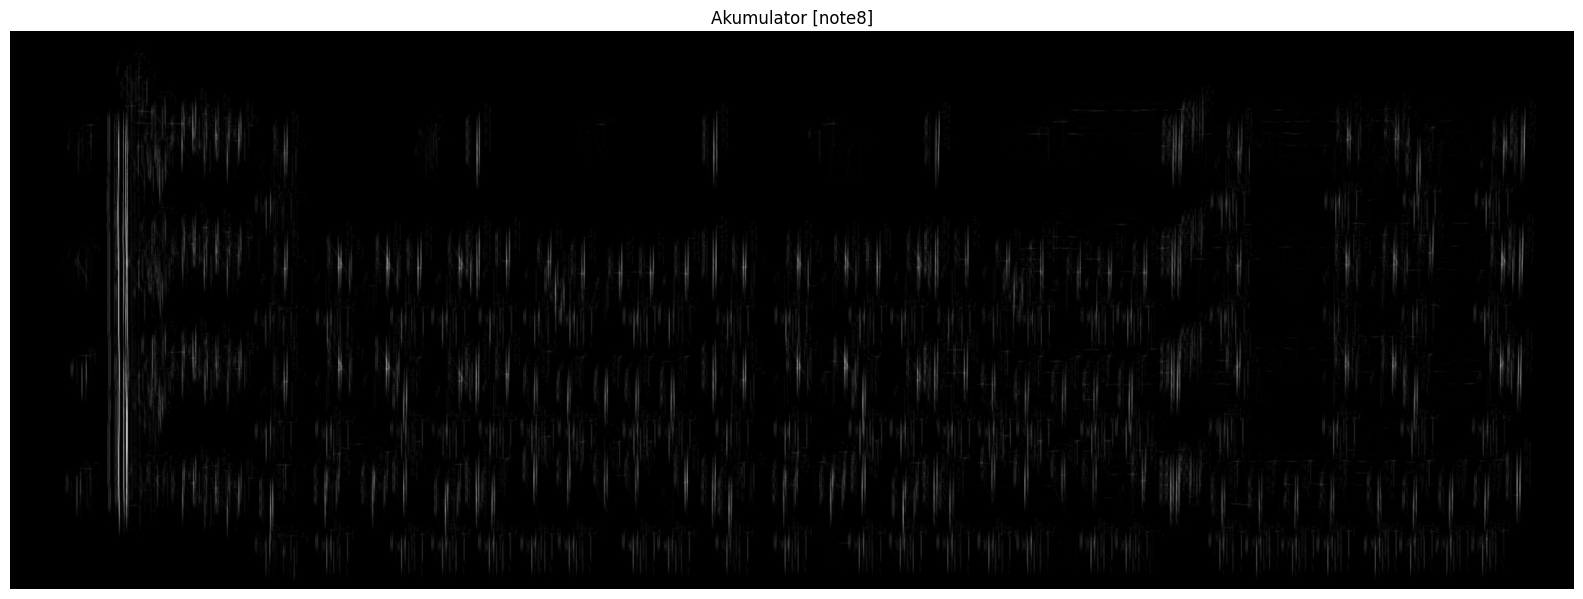

In [16]:
def ght_accumulate(r_table, xs_v, ys_v, ori_deg, H, W):
    """Glosowanie GHT. Zwraca akumulator (H, W) float32."""
    acc = np.zeros((H, W), dtype=np.float32)
    for x, y in zip(xs_v, ys_v):
        alpha = int(round(ori_deg[y, x])) % 360
        for r, fi in r_table.get(alpha, []):
            x1 = int(round(x - r * np.cos(fi)))
            y1 = int(round(y - r * np.sin(fi)))
            if 0 <= x1 < W and 0 <= y1 < H:
                acc[y1, x1] += 1.0
    return acc

def greedy_nms(acc, num_maxima, suppression_radius, min_votes=0, blur=BLUR_ACCUM):
    """Greedy argmax NMS (jak lab4 cell 9)."""
    acc_work = cv2.blur(acc.copy(), BLUR_KSIZE) if blur else acc.copy()
    H, W = acc_work.shape
    maxima = []
    for _ in range(num_maxima):
        idx = np.argmax(acc_work)
        y0, x0 = np.unravel_index(idx, acc_work.shape)
        val = float(acc[y0, x0])   # surowa wartosc (nie z blura)
        if val <= min_votes:
            break
        maxima.append((x0, y0, val))
        r = suppression_radius
        acc_work[max(0,y0-r):min(H,y0+r+1), max(0,x0-r):min(W,x0+r+1)] = 0
    return maxima

# ---- TEST -------------------------------------------------------
TEST_PAT = 'note8'
rt, pat_rel, cx0, cy0, n_pts = build_pattern(f'{PATTERNS_DIR}/{TEST_PAT}.png')
print(f'Wzorzec {TEST_PAT}: {n_pts} punktow konturu, centroid=({cx0:.1f},{cy0:.1f})')

t0 = time.time()
acc = ght_accumulate(rt, xs_vote, ys_vote, ori_s, H, W)
print(f'Czas GHT: {time.time()-t0:.2f}s  |  max akumulatora: {acc.max():.0f}')

maxima = greedy_nms(acc, NUM_MAXIMA, SUPPRESSION_RADIUS, MIN_VOTES)
print(f'Detekcji: {len(maxima)}')
for i,(x0,y0,v) in enumerate(maxima[:10]):
    print(f'  #{i+1:2d}  x={x0:4d}  y={y0:4d}  glosy={v:.0f}')

show_img(f'Akumulator [{TEST_PAT}]', (normalize01(acc)*255).astype(np.uint8), cmap='gray')

## 5. Wizualizacja detekcji (jeden wzorzec)

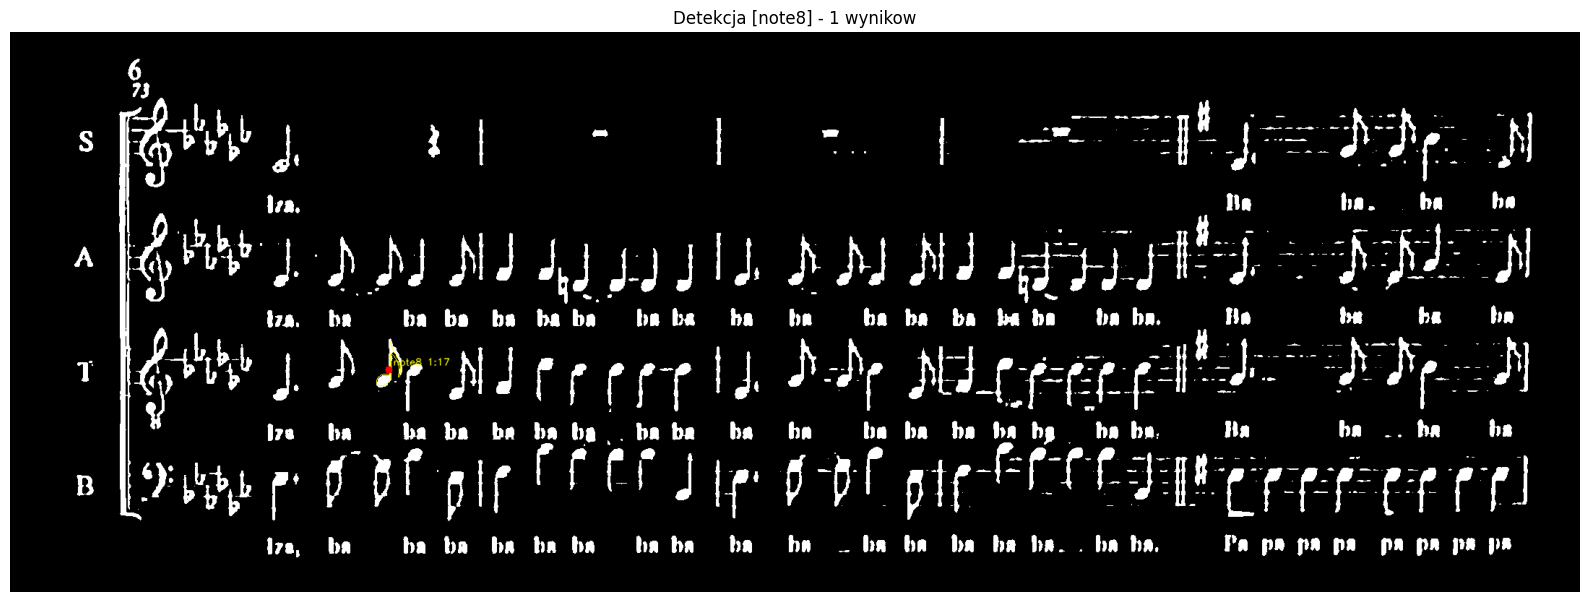

In [17]:
def draw_detections_one(scene_bgr, maxima, pattern_relative, color=(0,255,255), label=''):
    """Rysuje kontury wzorca w miejscach detekcji (jak lab4 cell 9)."""
    result = scene_bgr.copy()
    for i,(x0,y0,val) in enumerate(maxima, start=1):
        # Przesuniecie konturu
        cs = np.zeros_like(pattern_relative)
        cs[:,0] = pattern_relative[:,0] + x0
        cs[:,1] = pattern_relative[:,1] + y0
        cs = cs.astype(np.int32).reshape(-1,1,2)
        cv2.polylines(result, [cs], isClosed=True, color=color, thickness=1)
        cv2.circle(result, (x0,y0), 5, (0,0,255), -1)
        cv2.putText(result, f'{label}{i}:{val:.0f}', (x0+6,y0-6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1, cv2.LINE_AA)
    return result

result_one = draw_detections_one(scene_bgr, maxima, pat_rel, label=TEST_PAT+' ')
show_img(f'Detekcja [{TEST_PAT}] - {len(maxima)} wynikow', cv2.cvtColor(result_one, cv2.COLOR_BGR2RGB), h=8)

## 6. Pelna klasyfikacja – wszystkie wzorce

Dla kazdego wzorca:
1. Buduj R-table (konturowa)
2. Uruchom GHT na piksela sceny (amp>0.5)
3. Greedy NMS
4. Zbierz detekcje z etykieta wzorca

In [18]:
all_patterns = {}   # name -> {r_table, pat_rel, n_pts}
skipped = []

print(f"{'Wzorzec':<20} {'Pts':>6} {'Status'}")
print('-'*40)
for f in sorted(os.listdir(PATTERNS_DIR)):
    if not f.endswith('.png'): continue
    name = f[:-4]
    rt_i, pr_i, cx_i, cy_i, n_i = build_pattern(os.path.join(PATTERNS_DIR, f))
    if rt_i is None:
        skipped.append(name)
        print(f'{f:<20} {0:>6}  POMIN')
        continue
    all_patterns[name] = dict(r_table=rt_i, pat_rel=pr_i, cx=cx_i, cy=cy_i, n_pts=n_i)
    print(f'{f:<20} {n_i:>6}  OK')

print(f'\nZaladowano: {len(all_patterns)}  |  Pominieto: {skipped}')

Wzorzec                 Pts Status
----------------------------------------
12_8.png                319  OK
2_2.png                  74  OK
3_2.png                 147  OK
3_4.png                 176  OK
3_8.png                 113  OK
4_4.png                 259  OK
5_4.png                 165  OK
5_8.png                 121  OK
6_4.png                 184  OK
6_8.png                  81  OK
7_8.png                  78  OK
9_8.png                  84  OK
augmentation.png          0  POMIN
barline.png               0  POMIN
barline_double.png      128  OK
barline_end.png         126  OK
barline_repeat.png      156  OK
bemol.png                84  OK
bemol2.png              146  OK
clef_alt.png            202  OK
clef_bass.png           302  OK
clef_treble.png         192  OK
head2.png                36  OK
head4.png                29  OK
natural.png              32  OK
note1.png                35  OK
note16.png              196  OK
note16_.png             133  OK
note2.png             

In [19]:
# Kolory per kategoria
CAT_MAP = {
    **{n:(0,220,0) for n in ['note1','note2','note4','note8','note16','note32',
                              'note2_','note4_','note8_','note16_','note32_',
                              'note_8','note_16','note_32','note__8','note__16','head2','head4']},
    **{n:(220,100,0) for n in ['clef_treble','clef_bass','clef_alt']},
    **{n:(0,100,255) for n in ['2_2','3_2','3_4','3_8','4_4','5_4','5_8','6_4','6_8','7_8','9_8','12_8']},
    **{n:(200,0,200) for n in ['barline','barline_double','barline_end','barline_repeat']},
    **{n:(0,200,200) for n in ['bemol','bemol2','sharp','sharp2','natural']},
}

all_detections = {}   # name -> [(x,y,val), ...]
all_accumulators = {}
t_total = time.time()

for name, data in all_patterns.items():
    t1 = time.time()
    acc_i = ght_accumulate(data['r_table'], xs_vote, ys_vote, ori_s, H, W)
    mx_i  = greedy_nms(acc_i, NUM_MAXIMA, SUPPRESSION_RADIUS, MIN_VOTES)
    all_detections[name]    = mx_i
    all_accumulators[name]  = acc_i
    dt = time.time()-t1
    if mx_i:
        print(f'  {name:<20}  detekcji={len(mx_i):>3}  max_acc={acc_i.max():.0f}  ({dt:.1f}s)')

print(f'\nCzas lacznie: {time.time()-t_total:.1f}s')

  12_8                  detekcji=  1  max_acc=53  (10.0s)
  5_4                   detekcji=  5  max_acc=66  (6.9s)
  5_8                   detekcji=  1  max_acc=45  (4.7s)
  6_8                   detekcji=  2  max_acc=25  (3.2s)
  barline_double        detekcji= 30  max_acc=120  (8.9s)
  barline_end           detekcji= 30  max_acc=122  (8.9s)
  barline_repeat        detekcji=  1  max_acc=71  (10.4s)
  clef_alt              detekcji= 30  max_acc=179  (14.0s)
  clef_bass             detekcji= 13  max_acc=36  (7.3s)
  note16                detekcji=  5  max_acc=74  (8.9s)
  note2                 detekcji= 30  max_acc=53  (8.4s)
  note2_                detekcji=  3  max_acc=96  (8.1s)
  note32                detekcji=  8  max_acc=81  (9.9s)
  note32_               detekcji= 14  max_acc=71  (8.6s)
  note4                 detekcji= 30  max_acc=97  (8.2s)
  note4_                detekcji=  3  max_acc=96  (8.1s)
  note8                 detekcji=  1  max_acc=83  (10.0s)
  note_16               

## 7. Wizualizacja – wszystkie wykryte symbole na jednym obrazie

Laczna liczba detekcji: 286


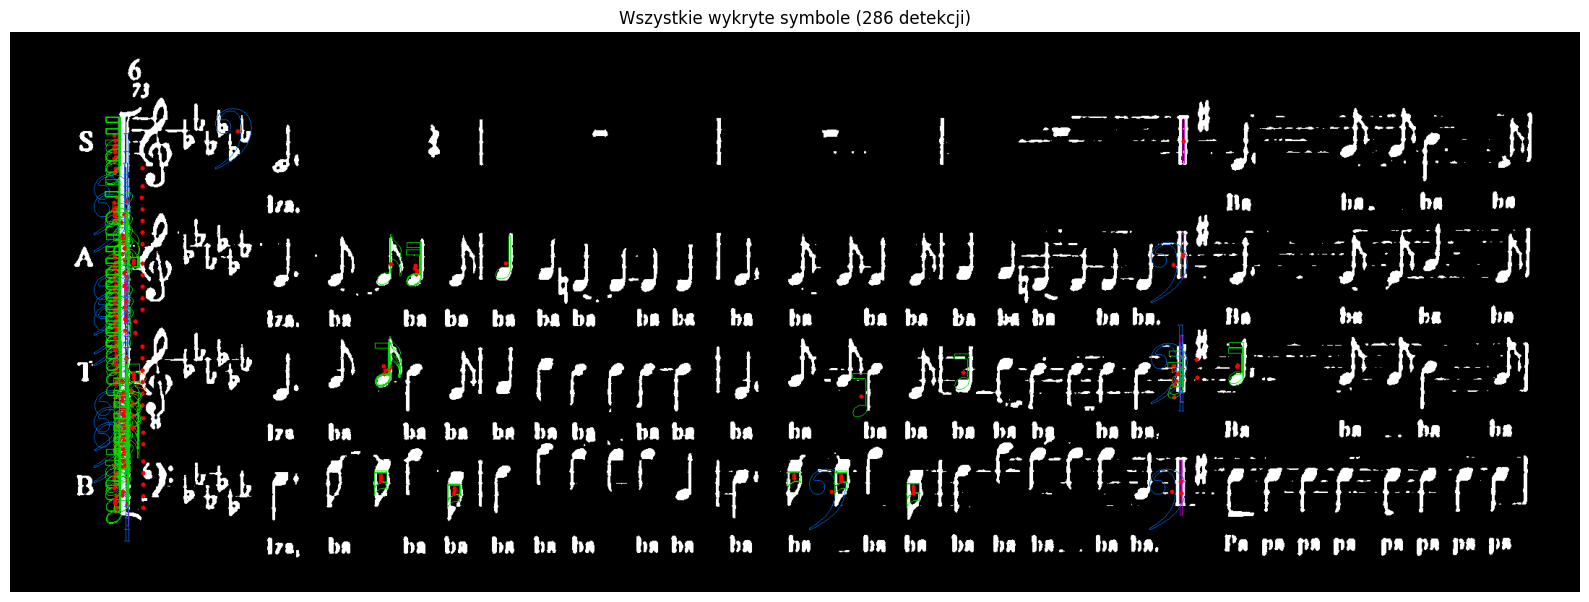

In [20]:
result_all = scene_bgr.copy()

total_det = 0
for name, maxima_i in all_detections.items():
    if not maxima_i: continue
    color = CAT_MAP.get(name, (150,150,0))
    pr_i  = all_patterns[name]['pat_rel']
    for (x0,y0,val) in maxima_i:
        cs = np.zeros_like(pr_i)
        cs[:,0] = pr_i[:,0] + x0
        cs[:,1] = pr_i[:,1] + y0
        cs = cs.astype(np.int32).reshape(-1,1,2)
        cv2.polylines(result_all, [cs], isClosed=True, color=color, thickness=1)
        cv2.circle(result_all, (x0,y0), 3, (0,0,255), -1)
        total_det += 1

print(f'Laczna liczba detekcji: {total_det}')
show_img(f'Wszystkie wykryte symbole ({total_det} detekcji)',
         cv2.cvtColor(result_all, cv2.COLOR_BGR2RGB), h=10)

## 8. Detekcje per wzorzec (podglad wybranych)

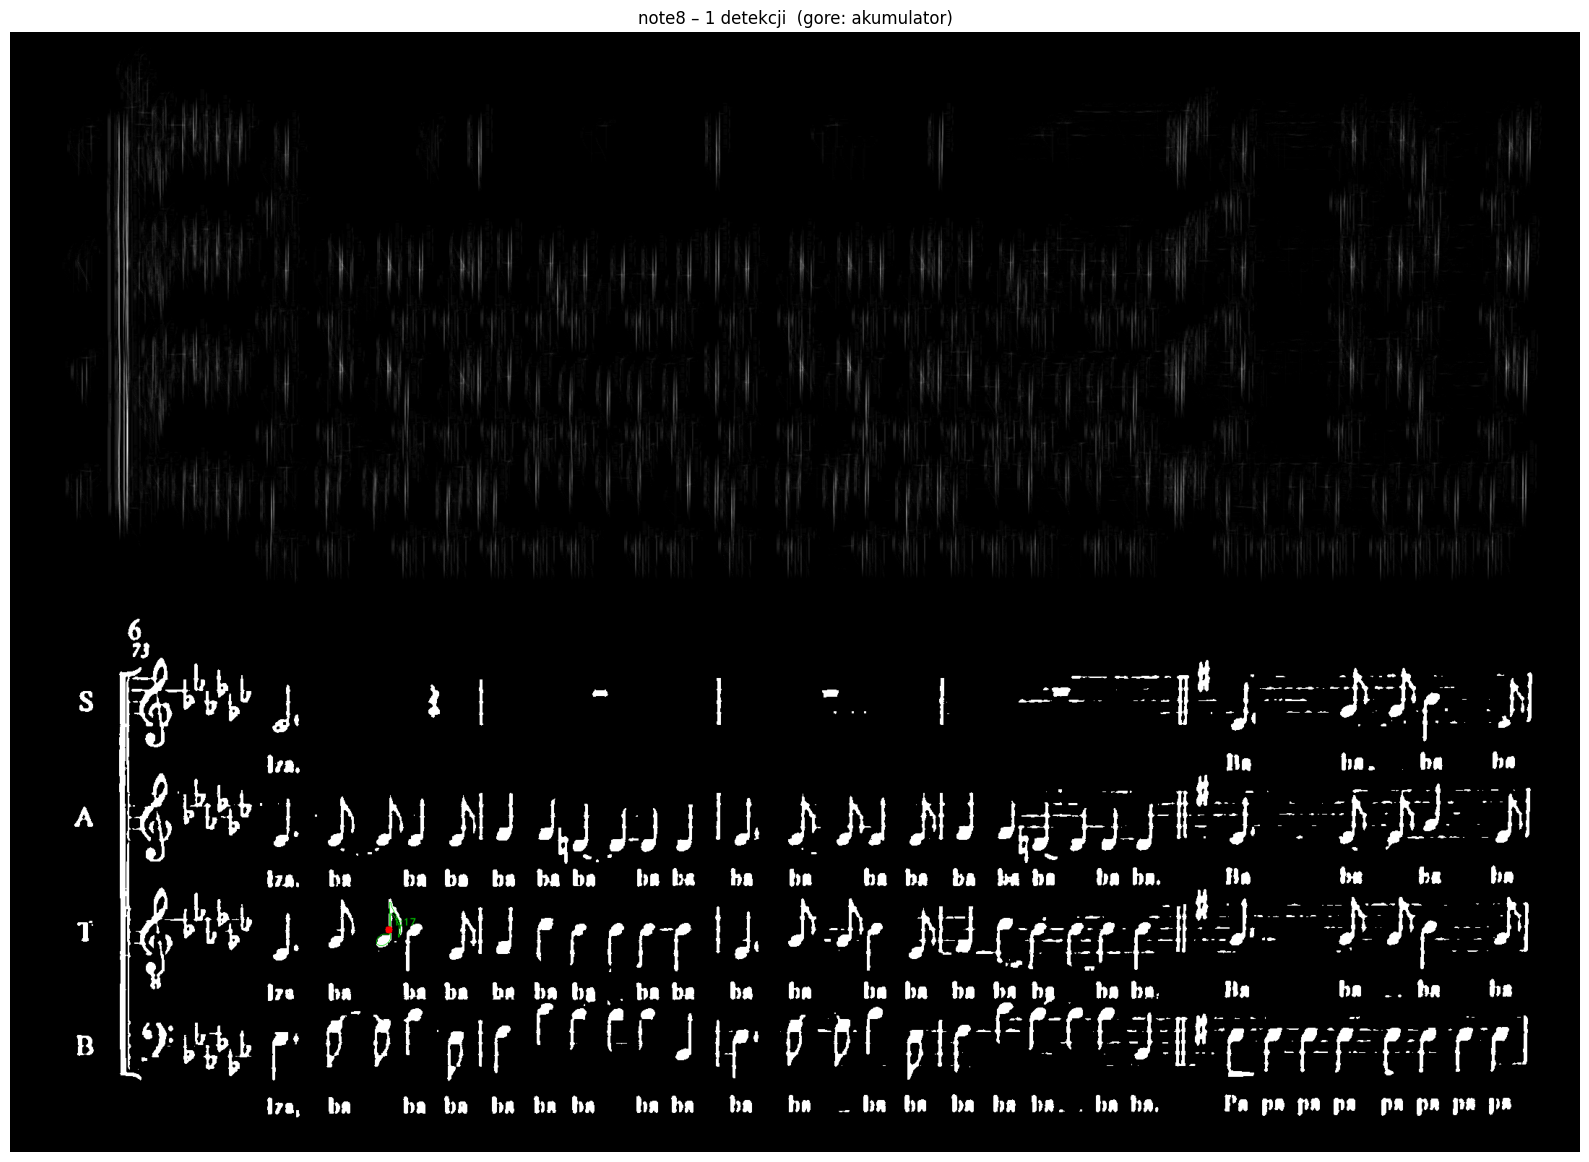

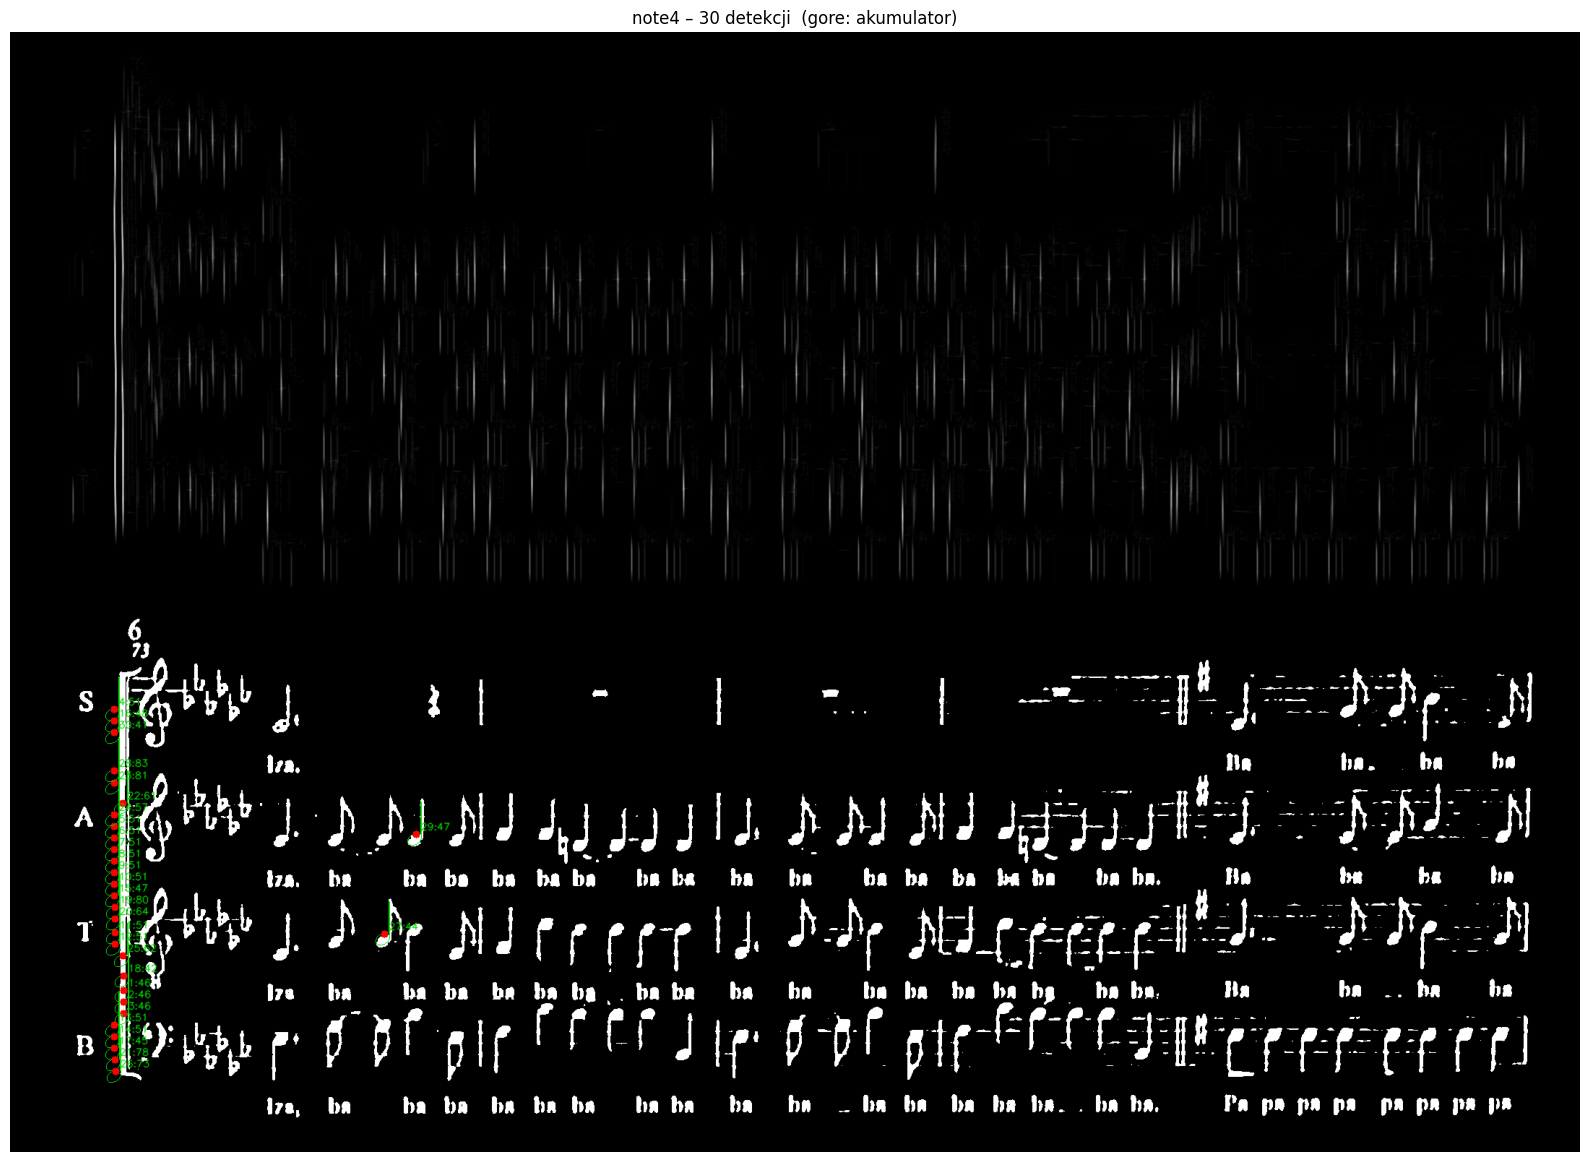

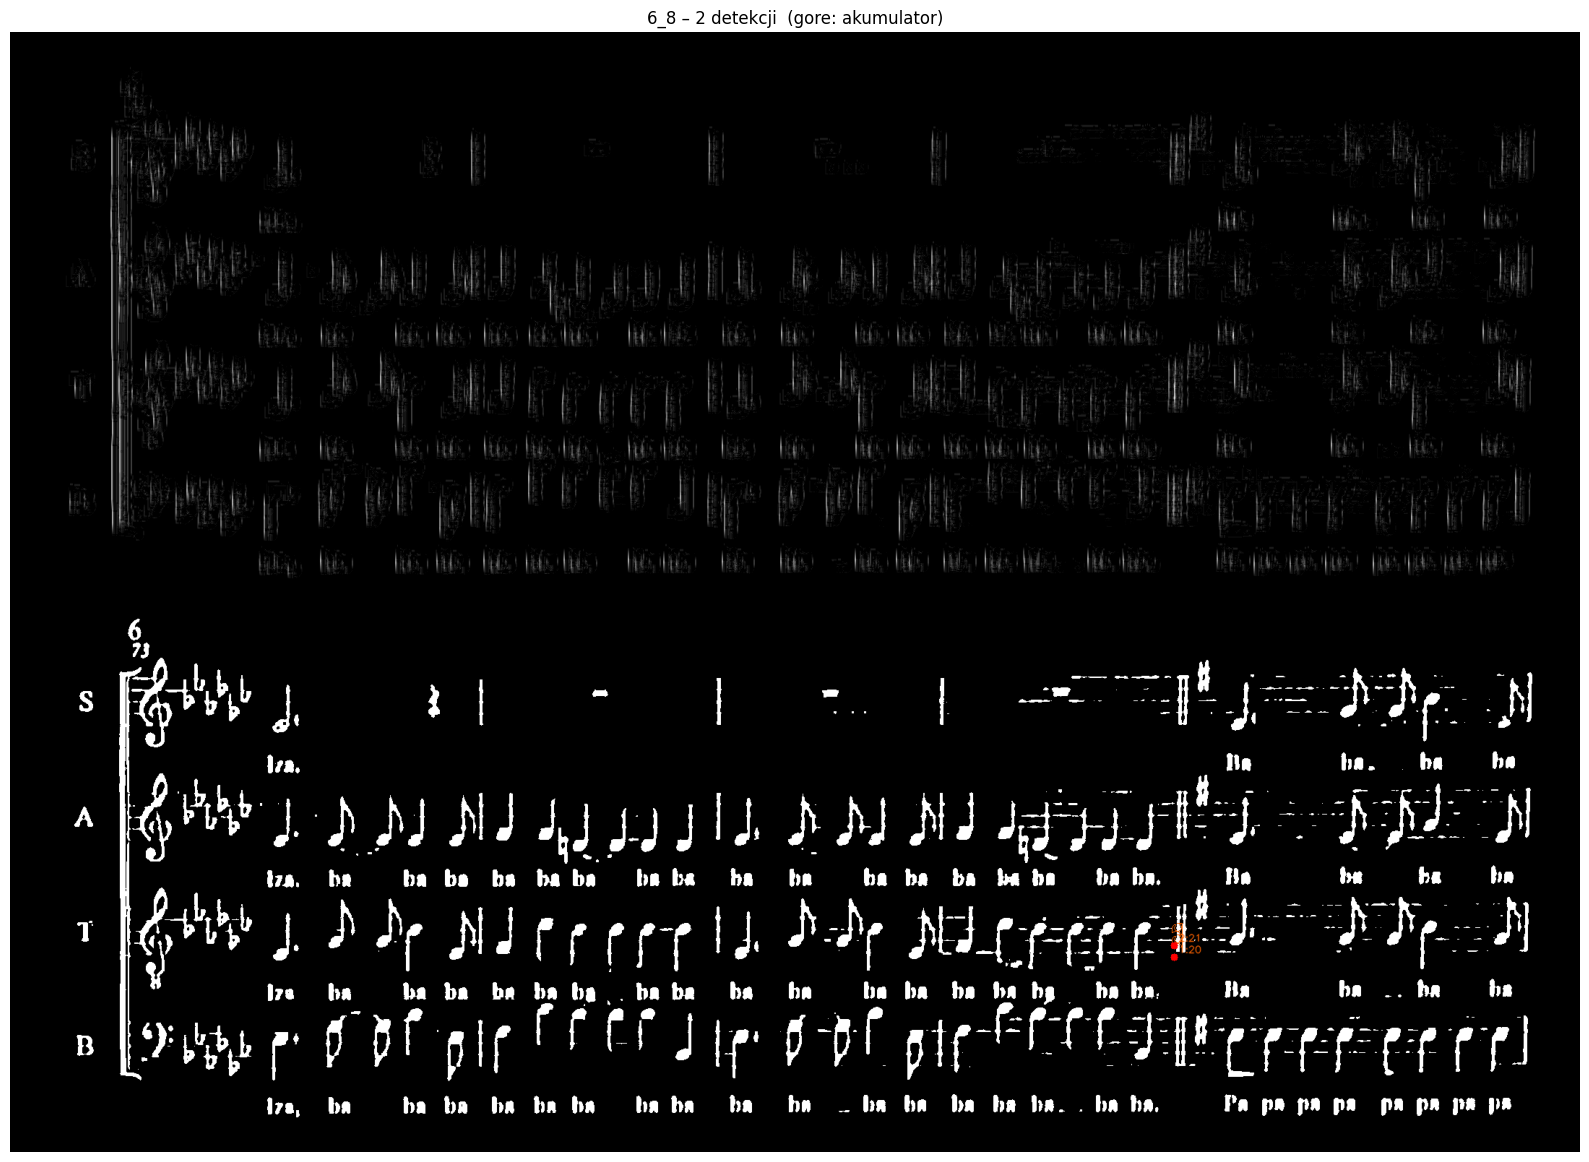

In [21]:
SHOW_PATTERNS = ['note8', 'note4', 'clef_treble', 'barline', 'bemol', '6_8']
SHOW_PATTERNS = [p for p in SHOW_PATTERNS if p in all_detections and all_detections[p]]

for name in SHOW_PATTERNS:
    mx = all_detections[name]
    pr = all_patterns[name]['pat_rel']
    acc = all_accumulators[name]
    color = CAT_MAP.get(name,(150,150,0))
    vis = draw_detections_one(scene_bgr, mx, pr, color=color)

    acc_vis = (normalize01(acc)*255).astype(np.uint8)
    acc_rgb = cv2.cvtColor(acc_vis, cv2.COLOR_GRAY2RGB)

    combined = cv2.vconcat([acc_rgb, cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)])
    show_img(f'{name} – {len(mx)} detekcji  (gore: akumulator)', combined, h=12)

## 9. Strojenie parametrow

Zmien `AMP_THRESH`, `SUPPRESSION_RADIUS`, `NUM_MAXIMA`, `MIN_VOTES` na gorze notatnika
i uruchom ponownie komorke 7 lub test na pojedynczym wzorcu.

Przydatne eksperymenty:
```python
# Mniej szumu w glosowaniu:
AMP_THRESH = 0.6  # tylko bardzo ostre krawedzie glosuja

# Wiecej/mniej detekcji:
MIN_VOTES = 25    # wyzszy prog absolutny

# Mniejszy NMS radius dla gestych symboli:
SUPPRESSION_RADIUS = 10
```